# Introduction

In this micro-course, you'll learn about different methods to wrangle and visualize geospatial data, or data with a geographic location.

Along the way, you'll offer solutions to several real-world problems like:

- Where should a global non-profit expand its reach in remote areas of the Philippines?
- How do purple martins, a threatened bird species, travel between North and South America? Are the birds travelling to conservation areas?
- Which areas of Japan could potentially benefit from extra earthquake reinforcement?
- Which Starbucks stores in California are strong candidates for the next Starbucks Reserve Roastery location?
- Does New York City have sufficient hospitals to respond to motor vehicle collisions? Which areas of the city have gaps in coverage?

You'll also visualize crime in the city of Boston, examine health facilities in Ghana, explore top universities in Europe, and track releases of toxic chemicals in the United States.

In [1]:
import geopandas as gpd
from pyprojroot.here import here

There are many, many different geospatial file formats, such as shapefile, GeoJSON, KML, and GPKG. We won't discuss their differences in this micro-course, but it's important to mention that:

- shapefile is the most common file type that you'll encounter, and
- all of these file types can be quickly loaded with the `gpd.read_file()` function.

The next code cell loads a shapefile containing information about forests, wilderness areas, and other lands under the care of the Department of Environmental Conservation in the state of New York.


In [12]:
full_data = gpd.read_file(here("data/DEC_lands/DEC_lands/DEC_lands.shp"))

In [4]:
full_data.head()

,OBJECTID,CATEGORY,UNIT,FACILITY,CLASS,UMP,DESCRIPTIO,REGION,COUNTY,URL,SOURCE,UPDATE_,OFFICE,ACRES,LANDS_UID,GREENCERT,SHAPE_AREA,SHAPE_LEN,geometry
0,1,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,NaN,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,738.620192,103,N,2.990365e+06,7927.662385,"POLYGON ((486093.245 4635308.586, 486787.235 4..."
1,2,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,NaN,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,282.553140,1218,N,1.143940e+06,4776.375600,"POLYGON ((491931.514 4637416.256, 491305.424 4..."
2,3,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,NaN,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,234.291262,1780,N,9.485476e+05,5783.070364,"POLYGON ((486000.287 4635834.453, 485007.55 46..."
3,4,FOR PRES DET PAR,CFP,GREENE COUNTY FP DETACHED PARCEL,WILD FOREST,NaN,NaN,4,GREENE,http://www.dec.ny.gov/,GREENE RPP,5/12,STAMFORD,450.106464,2060,N,1.822293e+06,7021.644833,"POLYGON ((541716.775 4675243.268, 541217.58 46..."
4,6,FOREST PRESERVE,AFP,SARANAC LAKES WILD FOREST,WILD FOREST,SARANAC LAKES,NaN,5,ESSEX,http://www.dec.ny.gov/lands/22593.html,"DECRP, ESSEX RPP",12/96,RAY BROOK,69.702387,1517,N,2.821959e+05,2663.909932,"POLYGON ((583896.043 4909643.187, 583891.2 490..."


As you can see in the "CLASS" column, each of the first five rows corresponds to a different forest.

For the rest of this tutorial, consider a scenario where you'd like to use this data to plan a weekend camping trip. Instead of relying on crowd-sourced reviews online, you decide to create your own map. This way, you can tailor the trip to your specific interests.

## Prerequisites
To view the first five rows of the data, we used the head() method. You may recall that this is also what we use to preview a Pandas DataFrame. In fact, every command that you can use with a DataFrame will work with the data!

This is because the data was loaded into a (GeoPandas) GeoDataFrame object that has all of the capabilities of a (Pandas) DataFrame.

In [5]:
type(full_data)

geopandas.geodataframe.GeoDataFrame

For instance, if we don't plan to use all of the columns, we can select a subset of them

In [6]:
data = full_data.loc[:, ["CLASS", "COUNTY", "geometry"]].copy()

We use the `value_counts()` method to see a list of different land types, along with how many times they appear in the dataset.

In [7]:
# How many lands of each type are there?
data.CLASS.value_counts()

CLASS
WILD FOREST                   965
INTENSIVE USE                 108
PRIMITIVE                      60
WILDERNESS                     52
ADMINISTRATIVE                 17
UNCLASSIFIED                    7
HISTORIC                        5
PRIMITIVE BICYCLE CORRIDOR      4
CANOE AREA                      1
Name: count, dtype: int64

You can also use `loc` (and `iloc`) and `isin` to select subsets of the data.

In [8]:
# Select lands that fall under the "WILD FOREST" or "WILDERNESS" category
wild_lands = data.loc[data.CLASS.isin(['WILD FOREST', 'WILDERNESS'])].copy()
wild_lands.head()

,CLASS,COUNTY,geometry
0,WILD FOREST,DELAWARE,"POLYGON ((486093.245 4635308.586, 486787.235 4..."
1,WILD FOREST,DELAWARE,"POLYGON ((491931.514 4637416.256, 491305.424 4..."
2,WILD FOREST,DELAWARE,"POLYGON ((486000.287 4635834.453, 485007.55 46..."
3,WILD FOREST,GREENE,"POLYGON ((541716.775 4675243.268, 541217.58 46..."
4,WILD FOREST,ESSEX,"POLYGON ((583896.043 4909643.187, 583891.2 490..."


# Create your first map!

We can quickly visualize the data with the `plot()` method. Note: requires matplotlib to be installed.

<Axes: >

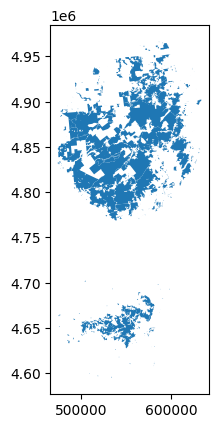

In [10]:
wild_lands.plot()

Every GeoDataFrame contains a special **"geometry"** column. It contains all of the geometric objects that are displayed when we call the `plot()` method.

In [11]:
# View the first five entries in the "geometry" column
wild_lands.geometry.head()

0    POLYGON ((486093.245 4635308.586, 486787.235 4...
1    POLYGON ((491931.514 4637416.256, 491305.424 4...
2    POLYGON ((486000.287 4635834.453, 485007.55 46...
3    POLYGON ((541716.775 4675243.268, 541217.58 46...
4    POLYGON ((583896.043 4909643.187, 583891.2 490...
Name: geometry, dtype: geometry

While this column can contain a variety of different datatypes, each entry will typically be a **Point**, **LineString**, or **Polygon**.


The "geometry" column in our dataset contains 2983 different Polygon objects, each corresponding to a different shape in the plot above.

In the code cell below, we create three more GeoDataFrames, containing campsite locations (Point), foot trails (LineString), and county boundaries (Polygon).

In [13]:
# Campsites in New York state (Point)
POI_data = gpd.read_file(here("data/DEC_pointsinterest/DEC_pointsinterest/Decptsofinterest.shp"))
campsites = POI_data.loc[POI_data.ASSET=='PRIMITIVE CAMPSITE'].copy()

# Foot trails in New York state (LineString)
roads_trails = gpd.read_file(here("data/DEC_roadstrails/DEC_roadstrails/Decroadstrails.shp"))
trails = roads_trails.loc[roads_trails.ASSET=='FOOT TRAIL'].copy()

# County boundaries in New York state (Polygon)
counties = gpd.read_file(here("data/NY_county_boundaries/NY_county_boundaries/NY_county_boundaries.shp"))

Next, we create a map from all four GeoDataFrames.

The plot() method takes as (optional) input several parameters that can be used to customize the appearance. Most importantly, setting a value for `ax` ensures that all of the information is plotted on the same map.

<Axes: >

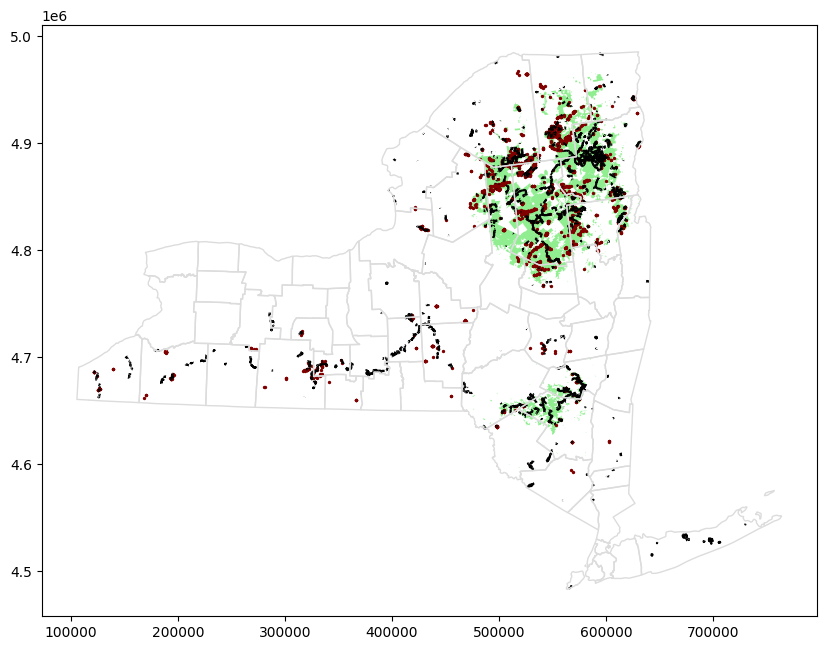

In [14]:
# Define a base map with county boundaries
ax = counties.plot(figsize=(10,10), color='none', edgecolor='gainsboro', zorder=3)

# Add wild lands, campsites, and foot trails to the base map
wild_lands.plot(color='lightgreen', ax=ax)
campsites.plot(color='maroon', markersize=2, ax=ax)
trails.plot(color='black', markersize=1, ax=ax)

It looks like the northeastern part of the state would be a great option for a camping trip!

# Exercises

In [2]:
loans_filepath = here("data/kiva_loans/kiva_loans/kiva_loans.shp")

# Your code here: Load the data
world_loans = gpd.read_file(loans_filepath)


In [9]:
print(world_loans.head())

   Partner ID                       Field Part                       sector  \
0           9  KREDIT Microfinance Institution  General Financial Inclusion   
1           9  KREDIT Microfinance Institution  General Financial Inclusion   
2           9  KREDIT Microfinance Institution  General Financial Inclusion   
3           9  KREDIT Microfinance Institution  General Financial Inclusion   
4           9  KREDIT Microfinance Institution  General Financial Inclusion   

               Loan Theme   country  amount                    geometry  
0        Higher Education  Cambodia     450  POINT (102.89751 13.66726)  
1  Vulnerable Populations  Cambodia   20275   POINT (102.98962 13.0287)  
2        Higher Education  Cambodia    9150   POINT (102.98962 13.0287)  
3  Vulnerable Populations  Cambodia  604950  POINT (105.31312 12.09829)  
4              Sanitation  Cambodia     275  POINT (105.31312 12.09829)  


In [4]:
world_filepath = here("data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
world = gpd.read_file(world_filepath)
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


<Axes: >

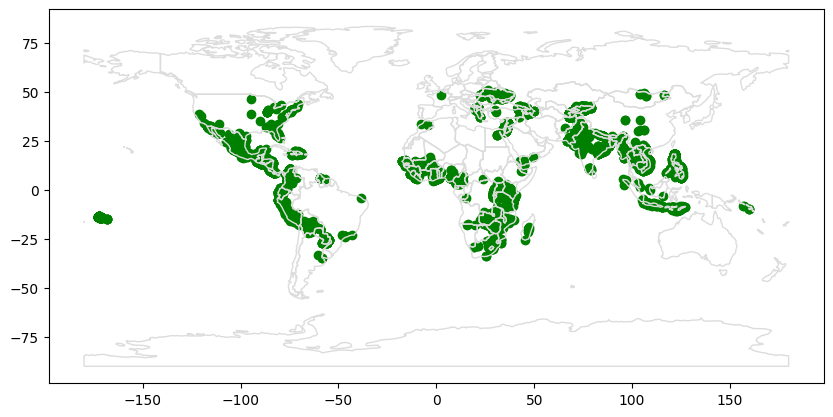

In [5]:
ax = world.plot(figsize=(10,10), color='none', edgecolor='gainsboro', zorder=3)

world_loans.plot(color='green', ax=ax)

## Explore loans in the Philippines


In [11]:
PHL_loans = world_loans.loc[world_loans.country == "Philippines"].copy()

In [13]:
PHL = gpd.read_file(here("data/Philippines_AL258.kml"), driver='KML')

,id,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,...,locname,offname,boundary,adminlevel,wikidata,wikimedia,note,rpath,ISO3166_2,geometry
0,3821409,Autonomous Region in Muslim Mindanao,None,2018-10-17 07:14:53,NaT,NaT,None,-1,0,-1,...,Autonomous Region in Muslim Mindanao,None,administrative,3,Q13708,en:Autonomous Region in Muslim Mindanao,None,"3821409,443174,0",PH-14,"MULTIPOLYGON (((119.4669 4.58718, 119.46653 4...."
1,3561455,Bicol Region,None,2018-10-17 07:14:53,NaT,NaT,None,-1,0,-1,...,Bicol,None,administrative,3,Q13662,en:Bicol Region,None,"3561455,443174,0",PH-05,"MULTIPOLYGON (((124.04577 11.57862, 124.04594 ..."
2,1552192,Cagayan Valley,None,2018-10-17 07:14:53,NaT,NaT,None,-1,0,-1,...,Cagayan Valley,None,administrative,3,Q13615,NaN,None,"1552192,443174,0",PH-02,"MULTIPOLYGON (((122.51581 17.04436, 122.51568 ..."
3,1552120,Calabarzon,None,2018-10-17 07:14:53,NaT,NaT,None,-1,0,-1,...,Calabarzon,None,administrative,3,Q13650,en:Calabarzon,None,"1552120,443174,0",PH-40,"MULTIPOLYGON (((120.49202 14.05403, 120.49201 ..."
4,3870502,Caraga,None,2018-10-17 07:14:53,NaT,NaT,None,-1,0,-1,...,Caraga,None,administrative,3,Q13704,NaN,None,"3870502,443174,0",PH-13,"MULTIPOLYGON (((126.45401 8.244, 126.45407 8.2..."


<Axes: >

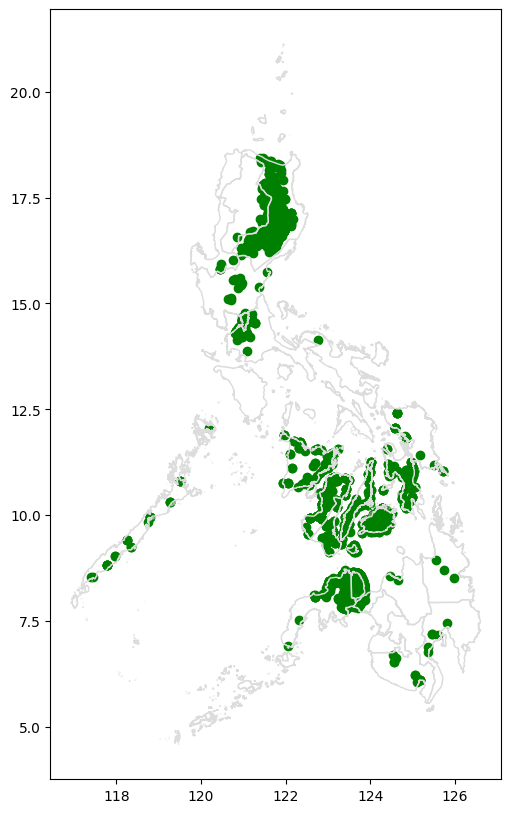

In [16]:
ax = PHL.plot(figsize=(10,10), color='none', edgecolor='gainsboro', zorder=3)
PHL_loans.plot(color='green', ax=ax)

## Below is a function to look for missing geometry in a KML file

In [17]:
import xml.etree.ElementTree as ET

def kml_has_geometry(file_path):
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        # KML namespace handling
        ns = {'kml': 'http://www.opengis.net/kml/2.2'}

        # Geometry tags to check
        geometry_tags = ['Point', 'LineString', 'Polygon', 'MultiGeometry', 'Model']

        for tag in geometry_tags:
            if root.findall(f".//kml:{tag}", ns):
                return True
        return False

    except ET.ParseError:
        print("Error: Invalid KML/XML format.")
        return False
    except FileNotFoundError:
        print("Error: File not found.")
        return False

# Example usage
file_path = here("data/Philippines_AL258.kml")
if kml_has_geometry(file_path):
    print("KML contains geometry data.")
else:
    print("No geometry data found in KML.")

KML contains geometry data.
